Using device: cpu
Epoch [1/5], Loss: 0.1995
Epoch [2/5], Loss: 0.0728
Epoch [3/5], Loss: 0.0498
Epoch [4/5], Loss: 0.0371
Epoch [5/5], Loss: 0.0282
Test Accuracy: 97.98%


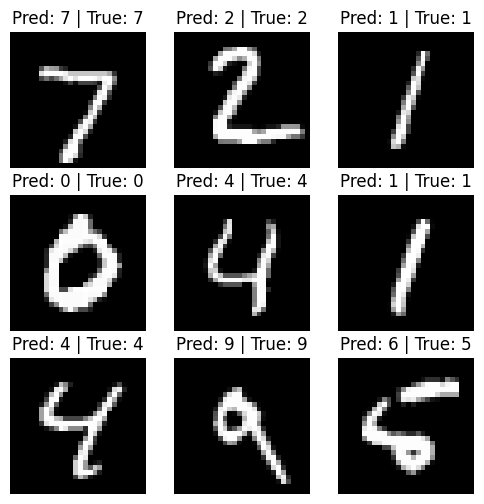

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# Transform: convert to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

'''
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)   # (input_channels, output_channels, kernel_size)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        
        # self.fc1 = nn.Linear(36864, 128)       # Fully connected layer
        # self.fc2 = nn.Linear(128, 10)         # 10 classes (digits 0–9)
        
        self.fc1 = nn.Linear(36864, 256)       # try changing 128 → 256
        self.fc2 = nn.Linear(256, 10)         # 10 classes (digits 0–9)
        
        # self.dropout = nn.Dropout(0.25)
        
        self.dropout = nn.Dropout(0.3)         # try changing 0.25 → 0.3

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

'''

# Activation Function Experimentation

#Activation function: LeakyReLU/Relu/Sigmoid/Tanh

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.act = nn.ReLU(0.01)  # Here we use LeakyReLU/Relu/Sigmoid/Tanh
        self.fc1 = nn.Linear(21632, 128)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x
    
    
# Initialize model, loss function, and optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

''' 
# Test convolutional layers 
model = CNNModel()

x = torch.randn(1, 1, 28, 28)  # One random MNIST-like image
output = model.conv1(x)
output = model.conv2(torch.relu(output))
print(output.shape)
'''

# Model training

epochs = 5  # You can increase for better accuracy

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


# Model evaluation

correct = 0
total = 0
model.eval()  # Evaluation mode (disable dropout)
with torch.no_grad():  # No gradient calculation needed
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


# Predict and visualize some test images

# Show a few predictions
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(3, 3, figsize=(6,6))
for i in range(9):
    ax = axes[i//3, i%3]
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    ax.axis('off')
plt.show()

